In [4]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
res='1km';t_res='5min'
Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 50M; Nz = 95
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc') #***
# res='1km'; t_res='1min_95nz'; Np_str='50e6'

In [5]:
times=data['time'].values/(1e9 * 60); times=times.astype(float);
minutes=1/times[1] #1 / minutes per timestep = timesteps per minute
kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)

In [6]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

#####

#Import StatisticalFunctions 
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import StatisticalFunctions
from StatisticalFunctions import * # import NumericalFunctions 

In [7]:
#LIMITING Y AXIS
limit_y=True
# limit_y=False

In [8]:
def limit_axes_to_y(ax, y_min=0, y_max=7, buffer_frac=0.1):
    ax.set_ylim(y_min, y_max)

    x_limited = []
    for line in ax.get_lines():
        xdata, ydata = np.array(line.get_xdata()), np.array(line.get_ydata())
        # Mask for y within limits
        y_mask = (ydata >= y_min) & (ydata <= y_max)
        # Apply mask
        x_visible = xdata[y_mask]
        # Remove NaN or Inf from x_visible
        x_visible = x_visible[np.isfinite(x_visible)]
        x_limited.extend(x_visible)
    if len(x_limited) > 0:
        x_limited = np.array(x_limited)
        x_min, x_max = np.min(x_limited), np.max(x_limited)

        if not (np.isfinite(x_min) and np.isfinite(x_max)):
            print("Warning: Non-finite x-limits detected, skipping set_xlim")
            return
        x_range = x_max - x_min

        if x_range == 0:
            buffer = 0.1  # fixed small buffer
        else:
            buffer = buffer_frac * x_range
        ax.set_xlim(x_min - buffer, x_max + buffer)
    else:
        print("Warning: No visible x data within y limits to set xlim")


In [9]:
#NEEDED TO PLOT THE CORRECT DATA #*#*
data_type="Tracked_Entrainment_VMF"

In [10]:
#CL VS NONCL

In [11]:
##################################
#PLOTTING

In [14]:
def LoadAllCloudBase():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"all_cloudbase_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        all_cloudbase = pickle.load(f)
    return(all_cloudbase)
min_all_cloudbase=np.nanmin(LoadAllCloudBase())
all_cloudbase=min_all_cloudbase
print(f"Minimum Cloudbase is: {all_cloudbase}\n")

Minimum Cloudbase is: 1.2463867664337158



In [15]:
def LoadMeanLFC():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"MeanLFC_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        MeanLFC = pickle.load(f)
    return MeanLFC
MeanLFC=LoadMeanLFC()
print(f"Mean LFC is: {MeanLFC}\n")

Mean LFC is: 1917.3723232782208



In [16]:
# #OLD
# types = ["ALL", "SHALLOW", "DEEP"]
# variables = ["VMF_c","VMF_g"]

# vars_list = []
# SE_list = []

# for t in types:
#     for var in variables:
#         vars_list.append(f"CL_{t}_profile_array_{var}")
#         vars_list.append(f"nonCL_{t}_profile_array_{var}")

# # Define directory and output file path
# dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
# input_file = dir3+f"CL_nonCL_tracked_eulerian_VMF_profiles_{res}_{t_res}_{Np_str}.h5"

# # Open the HDF5 file and read the stored datasets into dynamically named variables
# with h5py.File(input_file, 'r') as f:
#     for var in vars_list:
#         globals()[var] = f[f'{var}'][:]

In [17]:
type1='CL';type2='nonCL'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)
    print(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    # globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"])
    globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"])
    # print(key)

nonCL_SHALLOW_profile_array_VMF_G_squares


In [18]:
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] > 1)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

In [19]:
var_units = [
    ("VMF_C", "VMF_C (kg/m²/s)"),
    ("VMF_G", "VMF_G (kg/m²/s)"),
]

In [20]:
def plot_profiles_with_se(type1, var_units=None, limit_y=True, all_cloudbase=1.0, ax=None, linestyle='solid'):
    import matplotlib.gridspec as gridspec
    import numpy as np
    import matplotlib.pyplot as plt

    lw=0.8

    if var_units is None:
        raise ValueError("You must supply var_units as a list of (var, xlabel) tuples.")
    
    n_panels = len(var_units)
    profiles = []
    SE_profiles = []
    
    for var, label in var_units:
        profiles.append((
            globals()[f"{type1}_ALL_profile_array_{var.upper()}"].copy(),
            globals()[f"{type1}_SHALLOW_profile_array_{var.upper()}"].copy(),
            globals()[f"{type1}_DEEP_profile_array_{var.upper()}"].copy(),
            label
        ))
        SE_profiles.append((
            globals()[f"{type1}_ALL_profile_array_{var.upper()}_SE"].copy(),
            globals()[f"{type1}_SHALLOW_profile_array_{var.upper()}_SE"].copy(),
            globals()[f"{type1}_DEEP_profile_array_{var.upper()}_SE"].copy(),
            None
        ))

    # Create new axes if none provided
    if ax is None:
        fig = plt.figure(figsize=(12, 8))
        gs = gridspec.GridSpec(3, 3, figure=fig)
        ax = [fig.add_subplot(gs[i]) for i in range(n_panels)]
    else:
        fig = ax[0].get_figure()
        ax = np.ravel(ax)  # ensure it's flat

    colors = ['black', 'green', 'blue']
    labels = ['ALL', 'SHALLOW', 'DEEP']

    for i, ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel), 
            (ALL_SE, SHALLOW_SE, DEEP_SE, _)) in enumerate(zip(profiles, SE_profiles)):
        
        axis = ax[i]
        profile_list = [ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array]
        SE_profile_list = [ALL_SE, SHALLOW_SE, DEEP_SE]

        for profile, SE_profile, color, label in zip(profile_list, SE_profile_list, colors, labels):
            profile = averaged_profiles(profile)

            switch, factor = 1, 1
            if xlabel in [r'$q_v$ (g/kg)', r'$q_c+q_i$ (g/kg)', 'HMC (g/kg/s)']:
                profile[:, 0] *= 1000
                SE_profile[:, 0] *= 1000

            axis.fill_betweenx(profile[:, 1], 
                               profile[:, 0] - factor * SE_profile[:, 0] * switch,
                               profile[:, 0] + factor * SE_profile[:, 0] * switch,
                               color=color, alpha=0.05)
            axis.plot(profile[:, 0], profile[:, 1], color=color, label=label, linestyle=linestyle,lw=lw)

        axis.set_xlabel(xlabel)
        axis.set_ylabel('z (km)')
        axis.grid(True)
        axis.axhline(all_cloudbase, color='purple', linestyle='dashed')
        axis.axhline(MeanLFC/1000,color='green',linestyle='dashed')

        if i == 1:
            axis.legend(loc='upper center')
        if i == 6:
            apply_scientific_notation([axis])

    if ax is None:
        plt.suptitle(f'({type1} ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian Parcels')
        plt.tight_layout()
        plt.show()

    return fig, ax


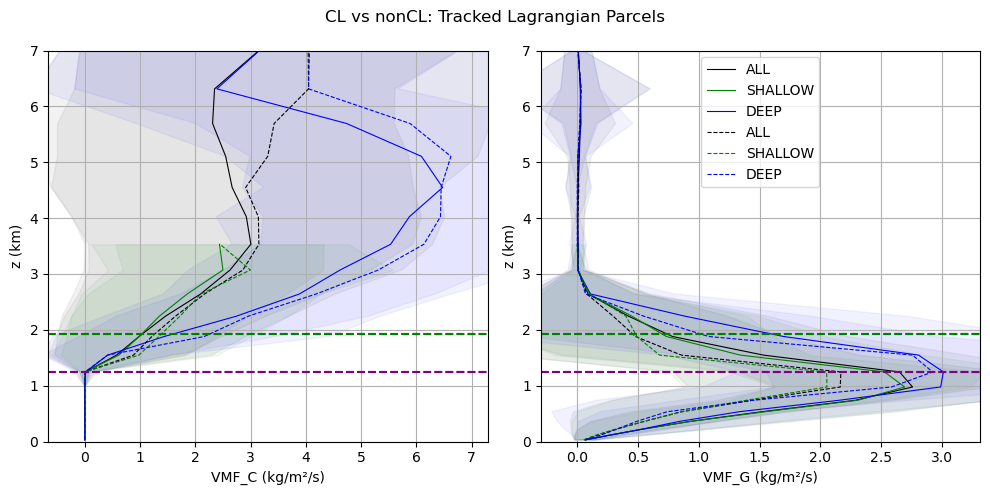

In [21]:
# Set up shared axes
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs = axs.flatten()

# Plot both types on same axes
plot_profiles_with_se('CL', var_units=var_units, limit_y=limit_y, all_cloudbase=all_cloudbase, ax=axs, linestyle='solid')
plot_profiles_with_se('nonCL', var_units=var_units, limit_y=limit_y, all_cloudbase=all_cloudbase, ax=axs, linestyle='dashed')

# Accessories
for ax in axs:
    ax.set_ylim(bottom=0)
    #LIMITING YAXIS TO BELOW 7 KM
    if limit_y==True: 
        limit_axes_to_y(ax,y_min=0, y_max=7)
plt.suptitle('CL vs nonCL: Tracked Lagrangian Parcels')
plt.tight_layout()
plt.show()


In [22]:
#DIFFERENCES

def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

var_names = [var[0] for var in var_units]
for var in var_names:
    for category in ["ALL", "SHALLOW", "DEEP"]:
        globals()[f"{category}_diff_{var}"] = average_difference(
            globals()[f"CL_{category}_profile_array_{var}"],
            globals()[f"nonCL_{category}_profile_array_{var}"]
        )

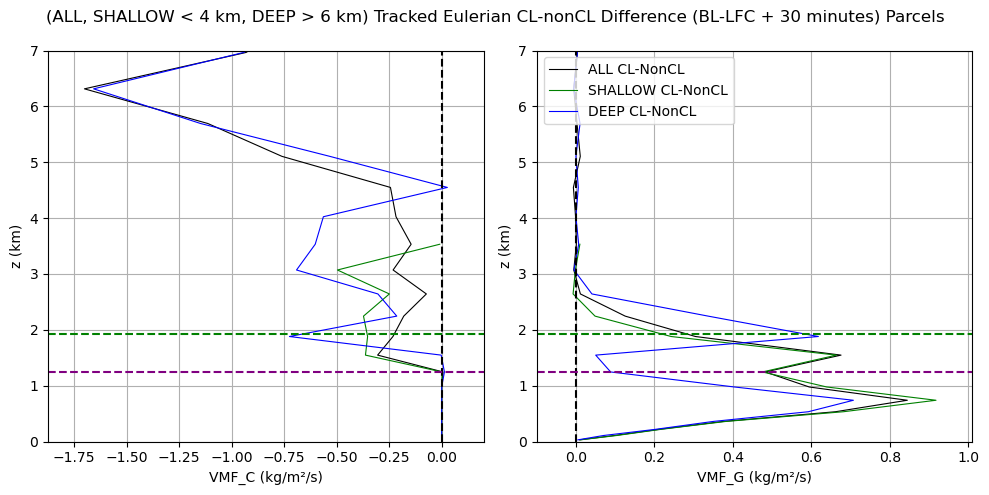

In [23]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

profiles = [
    (
        globals()[f"ALL_diff_{var}"].copy(),
        globals()[f"SHALLOW_diff_{var}"].copy(),
        globals()[f"DEEP_diff_{var}"].copy(),
        label
    )
    for var, label in var_units
]

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 2, figure=fig)
lw=0.8

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
    ax = fig.add_subplot(gs[i])

    
    # Compute the averaged profile
    ALL_profile = ALL_profile_array.copy()
    SHALLOW_profile = SHALLOW_profile_array.copy()
    DEEP_profile = DEEP_profile_array.copy()

    if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
        ALL_profile[:,0]*=1000
        SHALLOW_profile[:,0]*=1000
        DEEP_profile[:,0]*=1000
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, 1],color='black',label='ALL CL-NonCL',lw=lw)
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, 1],color='green',label='SHALLOW CL-NonCL',lw=lw)
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, 1],color='blue',label='DEEP CL-NonCL',lw=lw)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    ax.axvline(0,color='k',linestyle='dashed')

    #LEGEND
    if i==1:
        ax.legend(loc='upper left')
        
    # apply_scientific_notation([ax])

    #LIMITING YAXIS TO BELOW 7 KM
    if limit_y==True: 
        # #LIMITING YAXIS TO BELOW 7 KM
        limit_axes_to_y(ax,y_min=0, y_max=7)


#MEAN CLOUD BASE
axs = fig.get_axes()
ax1 = axs[0]; ax2 = axs[1]
for axis in [ax1,ax2]:
    axis.set_ylim(bottom=0)
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    axis.axhline(MeanLFC/1000,color='green',linestyle='dashed')
    
# #LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Eulerian CL-nonCL Difference (BL-LFC + 30 minutes) Parcels')
plt.tight_layout()



In [24]:
#SBZ vs NONSBZ
################################################################

In [25]:
##################################
#PLOTTING

In [26]:
# #OLD
# types = ["ALL", "SHALLOW", "DEEP"]
# variables = ["VMF_c","VMF_g"]

# vars_list = []
# SE_list = []

# for t in types:
#     for var in variables:
#         vars_list.append(f"SBZ_{t}_profile_array_{var}")
#         vars_list.append(f"nonSBZ_{t}_profile_array_{var}")

# # Define directory and output file path
# dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
# output_file = dir3+f"SBZ_nonSBZ_tracked_eulerian_VMF_profiles_{res}_{t_res}_{Np_str}.h5"

# # Open the HDF5 file and read the stored datasets into dynamically named variables
# with h5py.File(output_file, 'r') as f:
#     for var in vars_list:
#         globals()[var] = f[f'{var}'][:]

In [27]:
type1='SBZ';type2='nonSBZ'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    # globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"])
    globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"])

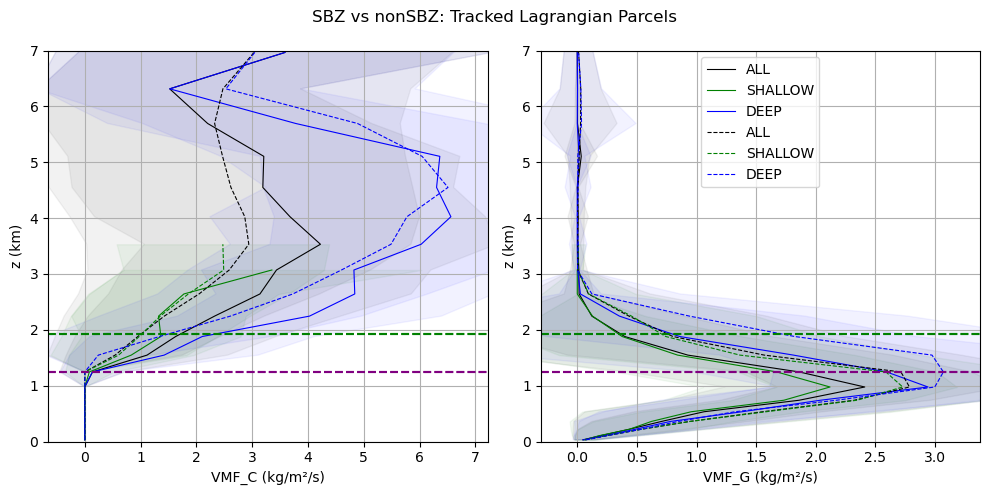

In [28]:
# Set up shared axes
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs = axs.flatten()

# Plot both types on same axes
plot_profiles_with_se('SBZ', var_units=var_units, limit_y=limit_y, all_cloudbase=all_cloudbase, ax=axs, linestyle='solid')
plot_profiles_with_se('nonSBZ', var_units=var_units, limit_y=limit_y, all_cloudbase=all_cloudbase, ax=axs, linestyle='dashed')

# Accessories
for ax in axs:
    ax.set_ylim(bottom=0)
    #LIMITING YAXIS TO BELOW 7 KM
    if limit_y==True: 
        limit_axes_to_y(ax,y_min=0, y_max=7)
# Accessories
plt.suptitle('SBZ vs nonSBZ: Tracked Lagrangian Parcels')
plt.tight_layout()
plt.show()


In [29]:
#SBZ vs nonSBZ
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile


var_names = [var[0] for var in var_units]
for var in var_names:
    for category in ["ALL", "SHALLOW", "DEEP"]:
        globals()[f"{category}_diff_{var}"] = average_difference(
            globals()[f"SBZ_{category}_profile_array_{var}"],
            globals()[f"nonSBZ_{category}_profile_array_{var}"]
        )

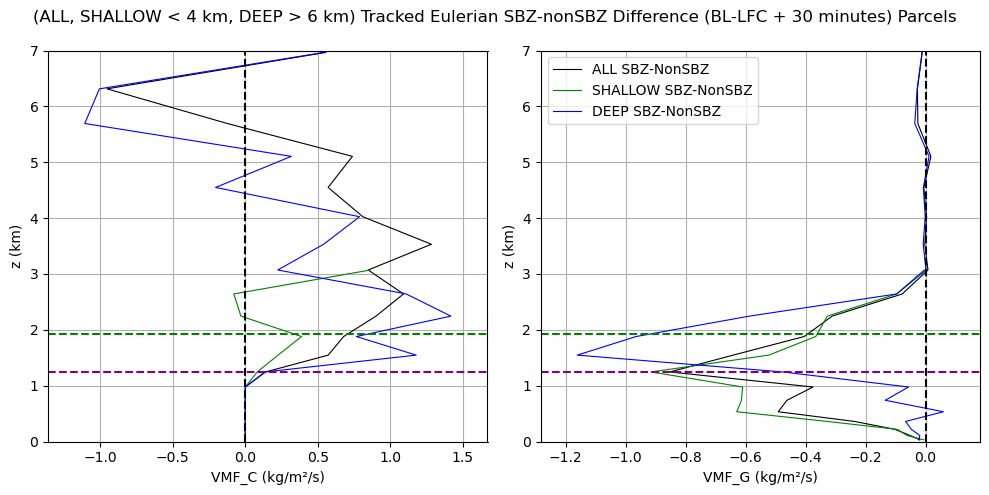

In [30]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

profiles = [
    (
        globals()[f"ALL_diff_{var}"].copy(),
        globals()[f"SHALLOW_diff_{var}"].copy(),
        globals()[f"DEEP_diff_{var}"].copy(),
        label
    )
    for var, label in var_units
]


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 2, figure=fig)
lw=0.8

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
    ax = fig.add_subplot(gs[i])

    
    # Compute the averaged profile
    ALL_profile = ALL_profile_array.copy()
    SHALLOW_profile = SHALLOW_profile_array.copy()
    DEEP_profile = DEEP_profile_array.copy()

    if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
        ALL_profile[:,0]*=1000
        SHALLOW_profile[:,0]*=1000
        DEEP_profile[:,0]*=1000
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, 1],color='black',label='ALL SBZ-NonSBZ',lw=0.8)
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, 1],color='green',label='SHALLOW SBZ-NonSBZ',lw=0.8)
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, 1],color='blue',label='DEEP SBZ-NonSBZ',lw=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    ax.axvline(0,color='k',linestyle='dashed')

    #LEGEND
    if i==1:
        ax.legend(loc='upper left')
        
    # apply_scientific_notation([ax])
    
    #LIMITING YAXIS TO BELOW 7 KM
    if limit_y==True: 
        limit_axes_to_y(ax,y_min=0, y_max=7)

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1 = axs[0]; ax2 = axs[1]
for axis in [ax1,ax2]:
    axis.set_ylim(bottom=0)
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    axis.axhline(MeanLFC/1000,color='green',linestyle='dashed')
    
# #LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Eulerian SBZ-nonSBZ Difference (BL-LFC + 30 minutes) Parcels')
plt.tight_layout()



In [31]:
#ColdPool
################################################################

In [32]:
#PLOTTING
############################################################

In [33]:
# #OLD
# types = ["ALL", "SHALLOW", "DEEP"]
# variables = ["VMF_c","VMF_g"]

# vars_list = []

# for t in types:
#     for var in variables:
#         vars_list.append(f"ColdPool_{t}_profile_array_{var}")

# # Define directory and output file path
# dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
# output_file = dir3 + f"ColdPool_tracked_eulerian_VMF_profiles_{res}_{t_res}_{Np_str}.h5"

# # Open the HDF5 file and read the stored datasets into dynamically named variables
# with h5py.File(output_file, 'r') as f:
#     for var in vars_list:
#         globals()[var] = f[f'{var}'][:]

In [34]:
type1='ColdPool'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    # globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"])
    globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"])
# print(key)

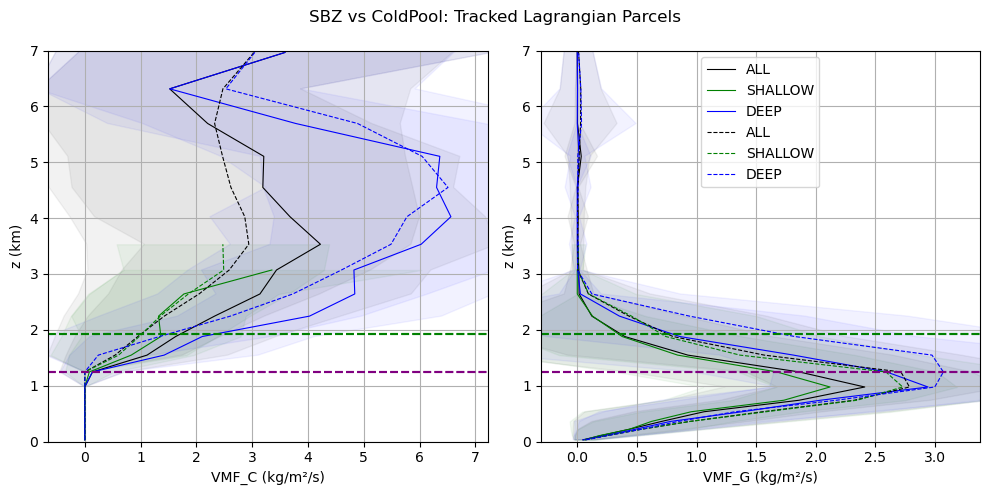

In [35]:
# Set up shared axes
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs = axs.flatten()

# Plot both types on same axes
plot_profiles_with_se('SBZ', var_units=var_units, limit_y=limit_y, all_cloudbase=all_cloudbase, ax=axs, linestyle='solid')
plot_profiles_with_se('ColdPool', var_units=var_units, limit_y=limit_y, all_cloudbase=all_cloudbase, ax=axs, linestyle='dashed')

# Accessories
for ax in axs:
    ax.set_ylim(bottom=0)
    #LIMITING YAXIS TO BELOW 7 KM
    if limit_y==True: 
        limit_axes_to_y(ax,y_min=0, y_max=7)
plt.suptitle('SBZ vs ColdPool: Tracked Lagrangian Parcels')
plt.tight_layout()
plt.show()


In [36]:
#SBZ vs ColdPool
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

var_names = [var[0] for var in var_units]
for var in var_names:
    for category in ["ALL", "SHALLOW", "DEEP"]:
        globals()[f"{category}_diff_{var}"] = average_difference(
            globals()[f"SBZ_{category}_profile_array_{var}"],
            globals()[f"ColdPool_{category}_profile_array_{var}"]
        )

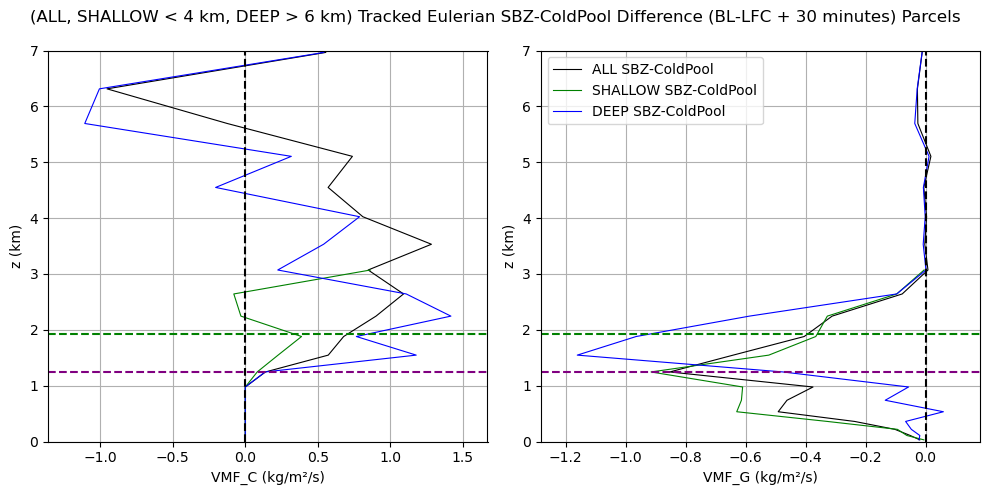

In [37]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

profiles = [
    (
        globals()[f"ALL_diff_{var}"].copy(),
        globals()[f"SHALLOW_diff_{var}"].copy(),
        globals()[f"DEEP_diff_{var}"].copy(),
        label
    )
    for var, label in var_units
]



# Set up the 2x3 gridspec
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 2, figure=fig)
lw=0.8

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
    ax = fig.add_subplot(gs[i])

    
    # Compute the averaged profile
    ALL_profile = ALL_profile_array.copy()
    SHALLOW_profile = SHALLOW_profile_array.copy()
    DEEP_profile = DEEP_profile_array.copy()

    if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
        ALL_profile[:,0]*=1000
        SHALLOW_profile[:,0]*=1000
        DEEP_profile[:,0]*=1000
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, 1],color='black',label='ALL SBZ-ColdPool',lw=lw)
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, 1],color='green',label='SHALLOW SBZ-ColdPool',lw=lw)
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, 1],color='blue',label='DEEP SBZ-ColdPool',lw=lw)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    ax.axvline(0,color='k',linestyle='dashed')

    #LEGEND
    if i==1:
        ax.legend(loc='upper left')

    # apply_scientific_notation([ax])

    #LIMITING YAXIS TO BELOW 7 KM
    if limit_y==True: 
        limit_axes_to_y(ax,y_min=0, y_max=7)


#MEAN CLOUD BASE
axs = fig.get_axes()
ax1 = axs[0]; ax2 = axs[1]
for axis in [ax1,ax2]:
    axis.set_ylim(bottom=0)
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    axis.axhline(MeanLFC/1000,color='green',linestyle='dashed')
    
# #LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Eulerian SBZ-ColdPool Difference (BL-LFC + 30 minutes) Parcels')
plt.tight_layout()

